In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# version of tensorflow
print(tf.__version__)

2.21.0


## Constant in Tensorflow

In [3]:
# About a Vector
from typing import Optional
def about_vector(
   vector, 
   shape: Optional[bool] = False,
   size: Optional[bool] = False,
   dtype: Optional[bool] = False,
   value: Optional[bool] = False,
   n_dim: Optional[bool] = False
) -> None:
   print(f"Vector: \n {vector}")
   print("-"*30)
   if shape:
     print(f"Shape of Vector: {vector.shape}") 
     print("-"*30)
   if size:
     print(f"Size of Vector: {tf.size(vector)}") 
     print("-"*30)
   if dtype:
     print(f"Datatype of Vector: {vector.dtype}") 
     print("-"*30)
   if value:
     print(f"Value of Vector: {vector.numpy()}") 
     print("-"*30)
   if n_dim:
     print(f"Dimention of Vector: {vector.ndim}")

In [4]:
# Constant tensorflow
scalar = tf.constant(2)
about_vector(
    vector=scalar,
    shape=True,
    dtype=True,
    value=True,
    n_dim=True
)

Vector: 
 2
------------------------------
Shape of Vector: ()
------------------------------
Datatype of Vector: <dtype: 'int32'>
------------------------------
Value of Vector: 2
------------------------------
Dimention of Vector: 0


In [5]:
matrix = tf.constant(
    [[1,2,3],
    [4,5,6]]
)
about_vector(
    vector=matrix,
    shape=True,
    dtype=True,
    value=True,
    n_dim=True
)

Vector: 
 [[1 2 3]
 [4 5 6]]
------------------------------
Shape of Vector: (2, 3)
------------------------------
Datatype of Vector: <dtype: 'int32'>
------------------------------
Value of Vector: [[1 2 3]
 [4 5 6]]
------------------------------
Dimention of Vector: 2


In [6]:
matrix_3_dim = tf.constant(
    [
        [[1,2,3],
        [4,5,6]],
        [[7,8,9],
        [10, 11, 12]]
    ], dtype=tf.float16
)
about_vector(
    vector=matrix_3_dim,
    shape=True,
    dtype=True,
    value=True,
    n_dim=True
)

Vector: 
 [[[ 1.  2.  3.]
  [ 4.  5.  6.]]

 [[ 7.  8.  9.]
  [10. 11. 12.]]]
------------------------------
Shape of Vector: (2, 2, 3)
------------------------------
Datatype of Vector: <dtype: 'float16'>
------------------------------
Value of Vector: [[[ 1.  2.  3.]
  [ 4.  5.  6.]]

 [[ 7.  8.  9.]
  [10. 11. 12.]]]
------------------------------
Dimention of Vector: 3


## Variable in Tensorflow

In [7]:
changeable_tensor = tf.Variable([10,7])
unchangeable_tensor = tf.constant([10,7])

about_vector(
    changeable_tensor,
    shape=True,
    dtype=True
)

about_vector(
    unchangeable_tensor,
    shape=True,
    dtype=True
)

Vector: 
 <tf.Variable 'Variable:0' shape=(2,) dtype=int32, numpy=array([10,  7], dtype=int32)>
------------------------------
Shape of Vector: (2,)
------------------------------
Datatype of Vector: <dtype: 'int32'>
------------------------------
Vector: 
 [10  7]
------------------------------
Shape of Vector: (2,)
------------------------------
Datatype of Vector: <dtype: 'int32'>
------------------------------


In [8]:
# try to change both of them
changeable_tensor[0].assign(7)
print(changeable_tensor)

<tf.Variable 'Variable:0' shape=(2,) dtype=int32, numpy=array([7, 7], dtype=int32)>


In [9]:
# try to change unchangeable_tensor
unchangeable_tensor[0].assign(7) 
# error: mean we cannot edit this constant tensor
print(unchangeable_tensor)

AttributeError: 'tensorflow.python.framework.ops.EagerTensor' object has no attribute 'assign'

## Random Tensor

In [ ]:
random_tensor = tf.random.uniform(shape = (3,4))
random_min_max_tensor = tf.random.uniform(
    shape = (3,4), 
    minval=-2, 
    maxval=1
)
print(random_tensor.numpy())
print("-"*30)
print(random_min_max_tensor.numpy())

[[0.9152049  0.3374864  0.41186345 0.6275574 ]
 [0.8002882  0.10644317 0.07544577 0.39874387]
 [0.9426464  0.37586594 0.89113116 0.52977395]]
------------------------------
[[-1.7757133  -1.1960926   0.2226739  -0.07669592]
 [ 0.73986244 -0.8568611   0.7091148  -0.24240243]
 [-0.5687772  -0.51873827 -0.18579853 -0.40601897]]


### Normally distributed random tensor

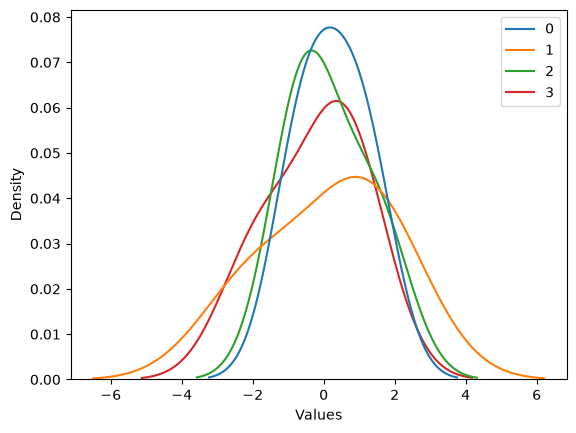

In [ ]:
normal_dis_random_tensor = tf.random.normal(shape=(3,4))

sns.kdeplot(normal_dis_random_tensor.numpy())
plt.xlabel("Values")
plt.ylabel("Density")
plt.show()

## tf.Ones and tf.Zeros

In [ ]:
ones = tf.ones(shape=[3,3])
ones

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]], dtype=float32)>

In [ ]:
zeros = tf.zeros(shape=[3,3], dtype=tf.int16)
zeros

<tf.Tensor: shape=(3, 3), dtype=int16, numpy=
array([[0, 0, 0],
       [0, 0, 0],
       [0, 0, 0]], dtype=int16)>

## Numpy array to tensor

In [ ]:
numpy_A = np.arange(1, 21, dtype=float)
numpy_A

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20.])

In [ ]:
# Method 1
numpy_A_tensor = tf.constant(numpy_A, shape=(2,5,2))
numpy_A_tensor

<tf.Tensor: shape=(2, 5, 2), dtype=float64, numpy=
array([[[ 1.,  2.],
        [ 3.,  4.],
        [ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.]],

       [[11., 12.],
        [13., 14.],
        [15., 16.],
        [17., 18.],
        [19., 20.]]])>

In [ ]:
# Method 2
numpy_A_tensor = tf.convert_to_tensor(numpy_A)
numpy_A_tensor

<tf.Tensor: shape=(20,), dtype=float64, numpy=
array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20.])>

In [ ]:
a = np.arange(81).reshape(3,3,3,3)
rank_4_tensor = tf.constant(a)

about_vector(
    rank_4_tensor,
    shape=True,
    size=True,
    dtype=True,
    value=True,
    n_dim=True
)

Vector: 
 [[[[ 0  1  2]
   [ 3  4  5]
   [ 6  7  8]]

  [[ 9 10 11]
   [12 13 14]
   [15 16 17]]

  [[18 19 20]
   [21 22 23]
   [24 25 26]]]


 [[[27 28 29]
   [30 31 32]
   [33 34 35]]

  [[36 37 38]
   [39 40 41]
   [42 43 44]]

  [[45 46 47]
   [48 49 50]
   [51 52 53]]]


 [[[54 55 56]
   [57 58 59]
   [60 61 62]]

  [[63 64 65]
   [66 67 68]
   [69 70 71]]

  [[72 73 74]
   [75 76 77]
   [78 79 80]]]]
------------------------------
Shape of Vector: (3, 3, 3, 3)
------------------------------
Size of Vector: 81
------------------------------
Datatype of Vector: <dtype: 'int64'>
------------------------------
Value of Vector: [[[[ 0  1  2]
   [ 3  4  5]
   [ 6  7  8]]

  [[ 9 10 11]
   [12 13 14]
   [15 16 17]]

  [[18 19 20]
   [21 22 23]
   [24 25 26]]]


 [[[27 28 29]
   [30 31 32]
   [33 34 35]]

  [[36 37 38]
   [39 40 41]
   [42 43 44]]

  [[45 46 47]
   [48 49 50]
   [51 52 53]]]


 [[[54 55 56]
   [57 58 59]
   [60 61 62]]

  [[63 64 65]
   [66 67 68]
   [69 70 71]]

  [[72

## Indexing in Tensor

tensor can be indexed like a python list.

In [ ]:
# second index
rank_4_tensor[1]

<tf.Tensor: shape=(3, 3, 3), dtype=int64, numpy=
array([[[27, 28, 29],
        [30, 31, 32],
        [33, 34, 35]],

       [[36, 37, 38],
        [39, 40, 41],
        [42, 43, 44]],

       [[45, 46, 47],
        [48, 49, 50],
        [51, 52, 53]]])>

In [ ]:
# till second index
rank_4_tensor[:2]

<tf.Tensor: shape=(2, 3, 3, 3), dtype=int64, numpy=
array([[[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8]],

        [[ 9, 10, 11],
         [12, 13, 14],
         [15, 16, 17]],

        [[18, 19, 20],
         [21, 22, 23],
         [24, 25, 26]]],


       [[[27, 28, 29],
         [30, 31, 32],
         [33, 34, 35]],

        [[36, 37, 38],
         [39, 40, 41],
         [42, 43, 44]],

        [[45, 46, 47],
         [48, 49, 50],
         [51, 52, 53]]]])>

In [ ]:
# till second index, only with 2nd element of all lists
rank_4_tensor[:2, 1]

<tf.Tensor: shape=(2, 3, 3), dtype=int64, numpy=
array([[[ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17]],

       [[36, 37, 38],
        [39, 40, 41],
        [42, 43, 44]]])>

In [ ]:
# till second index, till 2nd element of all lists
rank_4_tensor[:2, :2]

<tf.Tensor: shape=(2, 2, 3, 3), dtype=int64, numpy=
array([[[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8]],

        [[ 9, 10, 11],
         [12, 13, 14],
         [15, 16, 17]]],


       [[[27, 28, 29],
         [30, 31, 32],
         [33, 34, 35]],

        [[36, 37, 38],
         [39, 40, 41],
         [42, 43, 44]]]])>

In [ ]:
# till second index and till 2nd element of all lists
# and 2 rows of each list.
rank_4_tensor[:2, :2, 1]

<tf.Tensor: shape=(2, 2, 3), dtype=int64, numpy=
array([[[ 3,  4,  5],
        [12, 13, 14]],

       [[30, 31, 32],
        [39, 40, 41]]])>

In [ ]:
# till second index and till 2nd element of all lists
# and till 2nd ele of each list.
rank_4_tensor[:2, :2, :2]

<tf.Tensor: shape=(2, 2, 2, 3), dtype=int64, numpy=
array([[[[ 0,  1,  2],
         [ 3,  4,  5]],

        [[ 9, 10, 11],
         [12, 13, 14]]],


       [[[27, 28, 29],
         [30, 31, 32]],

        [[36, 37, 38],
         [39, 40, 41]]]])>

In [ ]:
# till second index and till 2nd element of all lists
# and till 2nd ele of each list.
# and 2nd element of the inner lists
rank_4_tensor[:2, :2, :2, 1]

<tf.Tensor: shape=(2, 2, 2), dtype=int64, numpy=
array([[[ 1,  4],
        [10, 13]],

       [[28, 31],
        [37, 40]]])>

In [ ]:
# till second index and till 2nd element of all lists
# and till 2nd ele of each list.
# and till 2nd element of the inner lists
rank_4_tensor[:2, :2, :2, :2]

<tf.Tensor: shape=(2, 2, 2, 2), dtype=int64, numpy=
array([[[[ 0,  1],
         [ 3,  4]],

        [[ 9, 10],
         [12, 13]]],


       [[[27, 28],
         [30, 31]],

        [[36, 37],
         [39, 40]]]])>

### practice

In [ ]:
rank_4_tensor[0, 1, 2, :]

<tf.Tensor: shape=(3,), dtype=int64, numpy=array([15, 16, 17])>

In [ ]:
rank_4_tensor[-1, :, 1:3, :2]

<tf.Tensor: shape=(3, 2, 2), dtype=int64, numpy=
array([[[57, 58],
        [60, 61]],

       [[66, 67],
        [69, 70]],

       [[75, 76],
        [78, 79]]])>

## Adding extra dimentions to tensor

In [11]:
rank_2_tensor = tf.constant(np.arange(1, 9).reshape(2,4))
about_vector(
    rank_2_tensor,
    shape=True,
    n_dim=True
)

Vector: 
 [[1 2 3 4]
 [5 6 7 8]]
------------------------------
Shape of Vector: (2, 4)
------------------------------
Dimention of Vector: 2


In [14]:
# Using expand_dims 
print(tf.expand_dims(rank_2_tensor, axis = -1))
print(rank_2_tensor)

tf.Tensor(
[[[1]
  [2]
  [3]
  [4]]

 [[5]
  [6]
  [7]
  [8]]], shape=(2, 4, 1), dtype=int64)
tf.Tensor(
[[1 2 3 4]
 [5 6 7 8]], shape=(2, 4), dtype=int64)


In [15]:
print(tf.expand_dims(rank_2_tensor, axis=0))

tf.Tensor(
[[[1 2 3 4]
  [5 6 7 8]]], shape=(1, 2, 4), dtype=int64)


## Operations in tensor

In [16]:
tensor = tf.constant([[10,7],[3,4]])
tensor + 10

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[20, 17],
       [13, 14]], dtype=int32)>

In [17]:
tensor * 10

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[100,  70],
       [ 30,  40]], dtype=int32)>

### tf.math

In [18]:
tensor

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[10,  7],
       [ 3,  4]], dtype=int32)>

In [29]:
print(tensor.numpy())
print("-"*30)
print(tf.math.add(tensor, 10).numpy())
print("-"*30)
print(tf.math.subtract(tensor, 10).numpy())
print("-"*30)
print(tf.math.multiply(tensor, 10).numpy())
print("-"*30)
print(tf.math.divide(tensor, 10).numpy())


[[10  7]
 [ 3  4]]
------------------------------
[[20 17]
 [13 14]]
------------------------------
[[ 0 -3]
 [-7 -6]]
------------------------------
[[100  70]
 [ 30  40]]
------------------------------
[[1.  0.7]
 [0.3 0.4]]


In [46]:
neg_tensor = tf.constant([-7,-10])
tf.abs(neg_tensor).numpy()

array([ 7, 10], dtype=int32)

### Matrix Multiplication

In [30]:
print(tensor)

tf.Tensor(
[[10  7]
 [ 3  4]], shape=(2, 2), dtype=int32)


In [31]:
tf.matmul(tensor, tensor) # dot product

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[121,  98],
       [ 42,  37]], dtype=int32)>

In [40]:
# dot product
tf.tensordot([[10,7], [3,4]], [[10,7], [3,4]], axes=1)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[121,  98],
       [ 42,  37]], dtype=int32)>

In [32]:
tensor * tensor

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[100,  49],
       [  9,  16]], dtype=int32)>

### Transpose of matrix

In [33]:
tf.transpose(rank_2_tensor)

<tf.Tensor: shape=(4, 2), dtype=int64, numpy=
array([[1, 5],
       [2, 6],
       [3, 7],
       [4, 8]])>

## Datatype of tensor (cast)

In [41]:
a = tf.constant([1,2,3,4])
b = tf.constant([1.2, 3.2])
print(a.dtype, b.dtype)

<dtype: 'int32'> <dtype: 'float32'>


In [44]:
d = tf.cast(b, dtype="float16")
# d = tf.cast(b, dtype=tf.float16) # both are correct
d.dtype

tf.float16

## Aggregating Tensors

In [57]:
E = tf.constant(np.random.randint(0, 100, size = 50))
E

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([84,  5, 94, 60, 88, 93, 59, 32, 10, 17, 95, 80, 97, 85, 11, 19, 82,
       76, 89, 88, 37, 53, 18, 71, 18, 86, 64, 84, 22, 77, 96, 38, 59, 52,
       57, 99, 33, 44, 43, 27, 93, 22, 18, 59, 23, 71, 12, 77, 15, 76],
      dtype=int32)>

In [58]:
# min value
tf.reduce_min(E)

<tf.Tensor: shape=(), dtype=int32, numpy=5>

In [60]:
# max value
tf.reduce_max(E)

<tf.Tensor: shape=(), dtype=int32, numpy=99>

In [61]:
# mean
tf.reduce_mean(E)

<tf.Tensor: shape=(), dtype=int32, numpy=56>

In [62]:
# Sum 
tf.reduce_sum(E)

<tf.Tensor: shape=(), dtype=int32, numpy=2808>

In [70]:
E = tf.cast(E, dtype=tf.float16)
variance = tf.math.reduce_variance(E)
std = tf.math.reduce_std(E)

print(f"Varience : {variance}")
print(f"Standard_Deviation_by_varience : {tf.math.sqrt(variance)}")
print(f"Standard Deviation : {std}")

Varience : 894.0
Standard_Deviation_by_varience : 29.90625
Standard Deviation : 29.90625


## Find Position of Max and Min Values

In [73]:
F = tf.random.uniform(shape=[50])
print(F)

tf.Tensor(
[0.3050598  0.8620055  0.26744068 0.8158796  0.11564326 0.9662626
 0.28798997 0.42802882 0.4943707  0.26129472 0.70973957 0.11424994
 0.28975034 0.07636952 0.6233814  0.30936086 0.6182904  0.62788856
 0.8881254  0.88986313 0.4537505  0.28679502 0.8307973  0.9373121
 0.15916717 0.12605238 0.2433821  0.05583763 0.8856448  0.6754763
 0.22205615 0.38536906 0.58522    0.683758   0.55453444 0.4756601
 0.654408   0.26872456 0.09968889 0.0837996  0.9092846  0.4135443
 0.72677255 0.4722215  0.2985506  0.5456114  0.8483324  0.295542
 0.0236429  0.3150612 ], shape=(50,), dtype=float32)


In [79]:
# Find the positional maximum
position = int(tf.argmax(F).numpy())
print(position)

# test
F[position]

5


<tf.Tensor: shape=(), dtype=float32, numpy=0.9662625789642334>

In [81]:
# find teh position of minimum
min_position = int(tf.argmin(F).numpy())
print(min_position)

48


In [85]:
# Sorted index of the array
sort_index = tf.argsort(F)
sort_index

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([48, 27, 13, 39, 38, 11,  4, 25, 24, 30, 26,  9,  2, 37, 21,  6, 12,
       47, 44,  0, 15, 49, 31, 41,  7, 20, 43, 35,  8, 45, 34, 32, 16, 14,
       17, 36, 29, 33, 10, 42,  3, 22, 46,  1, 28, 18, 19, 40, 23,  5],
      dtype=int32)>

In [94]:
[F[i].numpy() for i in sort_index]

[np.float32(0.023642898),
 np.float32(0.05583763),
 np.float32(0.076369524),
 np.float32(0.0837996),
 np.float32(0.09968889),
 np.float32(0.114249945),
 np.float32(0.11564326),
 np.float32(0.12605238),
 np.float32(0.15916717),
 np.float32(0.22205615),
 np.float32(0.2433821),
 np.float32(0.26129472),
 np.float32(0.26744068),
 np.float32(0.26872456),
 np.float32(0.28679502),
 np.float32(0.28798997),
 np.float32(0.28975034),
 np.float32(0.295542),
 np.float32(0.2985506),
 np.float32(0.3050598),
 np.float32(0.30936086),
 np.float32(0.3150612),
 np.float32(0.38536906),
 np.float32(0.4135443),
 np.float32(0.42802882),
 np.float32(0.4537505),
 np.float32(0.4722215),
 np.float32(0.4756601),
 np.float32(0.4943707),
 np.float32(0.5456114),
 np.float32(0.55453444),
 np.float32(0.58522),
 np.float32(0.6182904),
 np.float32(0.6233814),
 np.float32(0.62788856),
 np.float32(0.654408),
 np.float32(0.6754763),
 np.float32(0.683758),
 np.float32(0.70973957),
 np.float32(0.72677255),
 np.float32(0.815879

## Squeezing a tensor

In [98]:
G = tf.constant(np.arange(50).reshape(1,1,1,1,1,50))
G

<tf.Tensor: shape=(1, 1, 1, 1, 1, 50), dtype=int64, numpy=
array([[[[[[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13,
            14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27,
            28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41,
            42, 43, 44, 45, 46, 47, 48, 49]]]]]])>

In [99]:
G_squeeze = tf.squeeze(G)
G_squeeze

<tf.Tensor: shape=(50,), dtype=int64, numpy=
array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])>

## One Hot Encoding

In [105]:
some_list = [0,1,2,3]

tf.one_hot(some_list, depth=4)

<tf.Tensor: shape=(4, 4), dtype=float32, numpy=
array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]], dtype=float32)>

In [108]:
tf.one_hot(some_list, depth=4, on_value="**", off_value="-")

<tf.Tensor: shape=(4, 4), dtype=string, numpy=
array([[b'**', b'-', b'-', b'-'],
       [b'-', b'**', b'-', b'-'],
       [b'-', b'-', b'**', b'-'],
       [b'-', b'-', b'-', b'**']], dtype=object)>